<a href="https://colab.research.google.com/github/youssef12111/diabetes-multiclass-classification/blob/main/Assessment_2_Data_science.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Data Science Assessment 2 – Diabetes Multi-Class Classification (N / P / Y)

**Goal:** Build and compare models (Logistic Regression vs Random Forest) to classify patients as:
- **N** = Non-diabetic
- **P** = Prediabetic
- **Y** = Diabetic

I also include cross-validation and SHAP so the work is explainable (important for healthcare use).

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("Dataset_of_Diabetes.csv")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (1000, 14)
Columns: ['ID', 'No_Pation', 'Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS']


,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [ ]:
## 1) Quick Data Audit (structure + labels)
I first check the target column and make sure labels are consistent (e.g., "Y" vs "Y ").

In [ ]:
# Clean CLASS labels (handles "Y " etc.)
df["CLASS"] = df["CLASS"].astype(str).str.strip()

print("Unique CLASS values:", df["CLASS"].unique())
print("\nClass counts:")
print(df["CLASS"].value_counts())

print("\nClass percentages:")
print((df["CLASS"].value_counts(normalize=True) * 100).round(2))

Unique CLASS values: ['N' 'P' 'Y']

Class counts:
CLASS
Y    844
N    103
P     53
Name: count, dtype: int64

Class percentages:
CLASS
Y    84.4
N    10.3
P     5.3
Name: proportion, dtype: float64


In [ ]:
## Figure 1) Class Distribution
Because the dataset is imbalanced, I visualise the counts for N / P / Y.

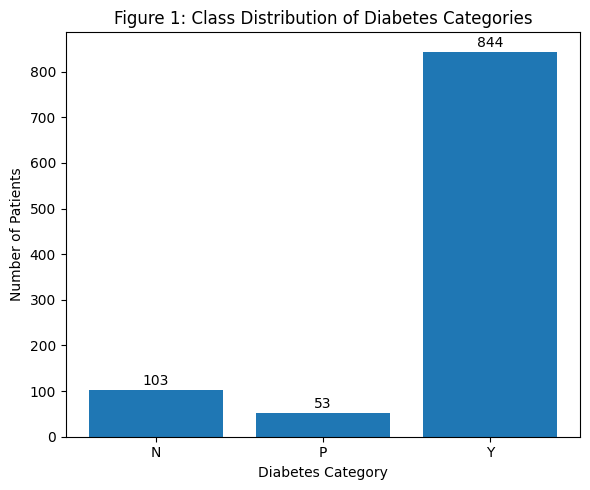

In [ ]:
import matplotlib.pyplot as plt

class_counts = df["CLASS"].value_counts().reindex(["N","P","Y"])

plt.figure(figsize=(6,5))
plt.bar(class_counts.index, class_counts.values)
plt.xlabel("Diabetes Category")
plt.ylabel("Number of Patients")
plt.title("Figure 1: Class Distribution of Diabetes Categories")

for i, v in enumerate(class_counts.values):
    plt.text(i, v + 10, str(v), ha="center")

plt.tight_layout()
plt.show()

In [ ]:
## 2) Missing Values Check
I confirm whether I need imputation. (In this dataset, it should be 0 missing.)

In [ ]:
missing = df.isna().sum()
print("Missing values per column:\n", missing)

print("\nPercentage missing:")
print(((missing / len(df)) * 100).round(2))

Missing values per column:
 ID           0
No_Pation    0
Gender       0
AGE          0
Urea         0
Cr           0
HbA1c        0
Chol         0
TG           0
HDL          0
LDL          0
VLDL         0
BMI          0
CLASS        0
dtype: int64

Percentage missing:
ID           0.0
No_Pation    0.0
Gender       0.0
AGE          0.0
Urea         0.0
Cr           0.0
HbA1c        0.0
Chol         0.0
TG           0.0
HDL          0.0
LDL          0.0
VLDL         0.0
BMI          0.0
CLASS        0.0
dtype: float64


In [ ]:
## 3) Skewness + Outlier Check (Triglycerides - TG)
TG looked skewed with extreme high values, so I check percentiles and decide whether to cap (winsorise).

In [ ]:
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns
print("Skewness (sorted):\n")
print(df[numeric_cols].skew().sort_values(ascending=False))

print("\nTG summary:")
print(df["TG"].describe())

print("\nTG percentiles:")
print(df["TG"].quantile([0.01, 0.05, 0.95, 0.99]))

Skewness (sorted):

No_Pation    19.561029
Cr            8.474151
HDL           6.283201
VLDL          5.350445
Urea          4.298928
TG            2.298456
LDL           1.145910
Chol          0.617123
ID            0.332679
HbA1c         0.221689
BMI           0.125807
AGE          -0.819536
dtype: float64

TG summary:
count    1000.000000
mean        2.349610
std         1.401176
min         0.300000
25%         1.500000
50%         2.000000
75%         2.900000
max        13.800000
Name: TG, dtype: float64

TG percentiles:
0.01    0.6
0.05    0.8
0.95    5.1
0.99    7.0
Name: TG, dtype: float64


In [ ]:
## Figure 2) TG Histogram (Before vs After Winsorisation)
I cap TG at the 99th percentile instead of deleting rows (could be clinically valid extreme patients).

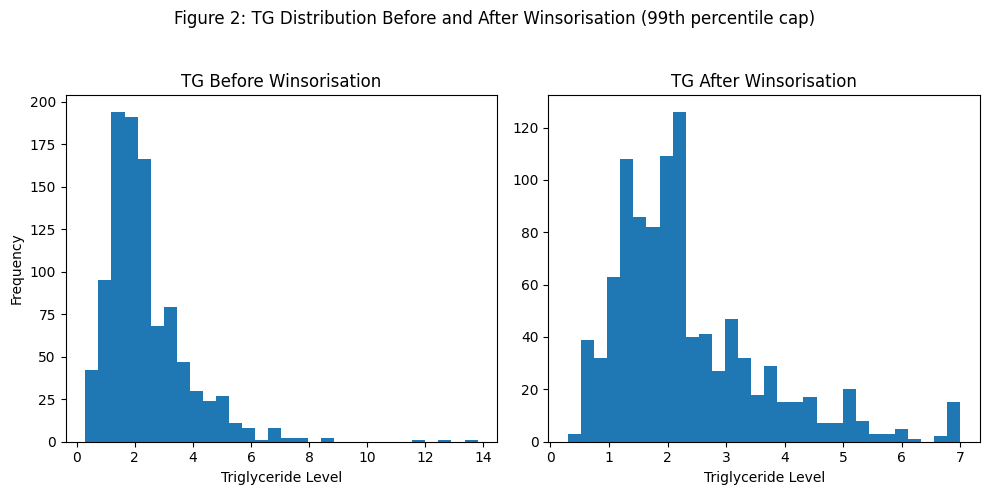

TG cap used (99th percentile): 7.0
New TG max: 7.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

tg_original = df["TG"].copy()
tg_cap = np.percentile(tg_original, 99)
tg_winsorised = tg_original.clip(upper=tg_cap)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.hist(tg_original, bins=30)
plt.title("TG Before Winsorisation")
plt.xlabel("Triglyceride Level")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(tg_winsorised, bins=30)
plt.title("TG After Winsorisation")
plt.xlabel("Triglyceride Level")

plt.suptitle("Figure 2: TG Distribution Before and After Winsorisation (99th percentile cap)", fontsize=12)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

# Apply the winsorised TG back into df
df["TG"] = tg_winsorised
print("TG cap used (99th percentile):", round(tg_cap, 3))
print("New TG max:", round(df["TG"].max(), 3))

In [ ]:
## 4) Clean + Encode Gender
I make Gender consistent (handles 'M', 'F', lowercase, spaces). Then encode to 1/0.

In [ ]:
def clean_gender(g):
    if pd.isna(g):
        return np.nan
    s = str(g).strip().upper()
    if s in ["M", "MALE", "1", "1.0"]:
        return 1
    if s in ["F", "FEMALE", "0", "0.0"]:
        return 0
    return np.nan

print("Gender uniques BEFORE:", df["Gender"].unique())
df["Gender"] = df["Gender"].apply(clean_gender)
print("Gender uniques AFTER:", df["Gender"].unique())

# if any NaN left (rare), fill with mode
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

df.head()

Gender uniques BEFORE: ['F' 'M' 'f']
Gender uniques AFTER: [0 1]


,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,1,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,1,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [ ]:
## 5) Train/Test Split (Stratified)
I use stratify=y because classes are imbalanced.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["CLASS"])
y = df["CLASS"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train class distribution:\n", (y_train.value_counts(normalize=True)*100).round(2))
print("\nTest class distribution:\n", (y_test.value_counts(normalize=True)*100).round(2))

Train class distribution:
 CLASS
Y    84.38
N    10.25
P     5.38
Name: proportion, dtype: float64

Test class distribution:
 CLASS
Y    84.5
N    10.5
P     5.0
Name: proportion, dtype: float64


In [ ]:
## 6) Model 1 — Logistic Regression (Baseline)
I use a pipeline with scaling. Macro F1 is the key metric because of class imbalance.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        solver="lbfgs",
        random_state=42
    ))
])

lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

lr_f1 = f1_score(y_test, pred_lr, average="macro")
print("Logistic Regression Macro F1:", round(lr_f1, 3))
print("\nClassification report:\n", classification_report(y_test, pred_lr))

Logistic Regression Macro F1: 0.805

Classification report:
               precision    recall  f1-score   support

           N       0.86      0.90      0.88        21
           P       0.47      0.70      0.56        10
           Y       0.99      0.95      0.97       169

    accuracy                           0.94       200
   macro avg       0.77      0.85      0.80       200
weighted avg       0.95      0.94      0.94       200



In [ ]:
## 7) Model 2 — Random Forest (Nonlinear)
Random Forest can capture nonlinear interactions and usually handles tabular clinical data well.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced_subsample"
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

rf_f1 = f1_score(y_test, pred_rf, average="macro")
print("Random Forest Macro F1:", round(rf_f1, 3))
print("\nClassification report:\n", classification_report(y_test, pred_rf))

Random Forest Macro F1: 0.981

Classification report:
               precision    recall  f1-score   support

           N       1.00      1.00      1.00        21
           P       1.00      0.90      0.95        10
           Y       0.99      1.00      1.00       169

    accuracy                           0.99       200
   macro avg       1.00      0.97      0.98       200
weighted avg       1.00      0.99      0.99       200



In [ ]:
## Figure 4) Model Comparison (Macro F1)
This is the clean evidence that Random Forest beats the baseline.

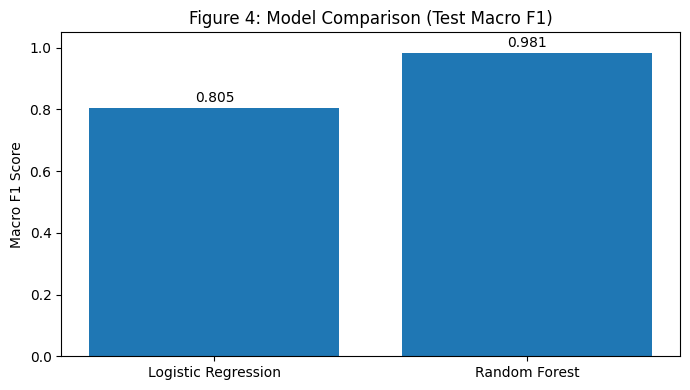

In [ ]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Random Forest"]
scores = [lr_f1, rf_f1]

plt.figure(figsize=(7,4))
plt.bar(models, scores)
plt.ylim(0, 1.05)
plt.ylabel("Macro F1 Score")
plt.title("Figure 4: Model Comparison (Test Macro F1)")

for i, v in enumerate(scores):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()

In [ ]:
## Figure 5) Random Forest Confusion Matrix
This shows exactly where the model makes mistakes (important for healthcare discussion).

<Figure size 600x500 with 0 Axes>

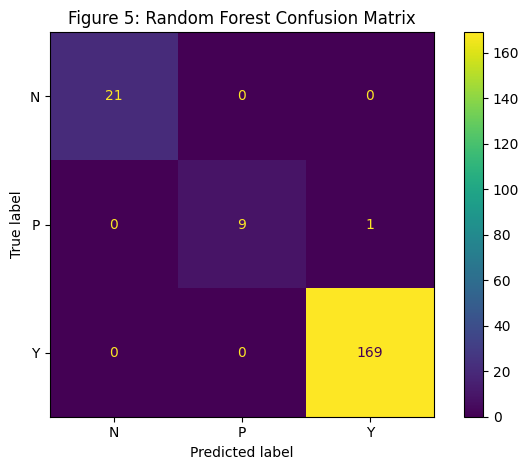

array([[ 21,   0,   0],
       [  0,   9,   1],
       [  0,   0, 169]])

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_order = ["N","P","Y"]
cm = confusion_matrix(y_test, pred_rf, labels=class_order)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order)
plt.figure(figsize=(6,5))
disp.plot(values_format="d")
plt.title("Figure 5: Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

cm

In [ ]:
## Figure 3) 5-Fold Cross-Validation Stability (Macro F1)
I run cross-validation to show the model is stable and not just lucky on one split.

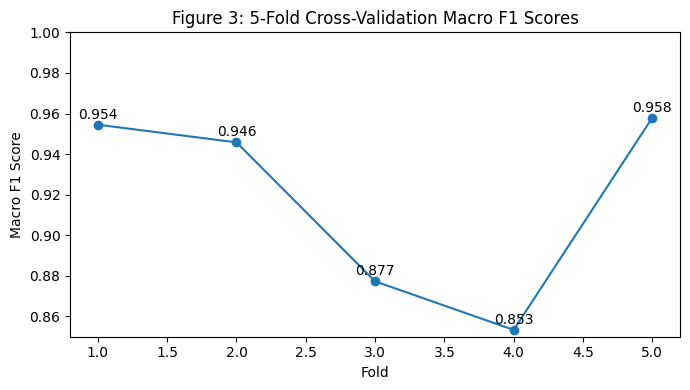

CV Mean: 0.918
CV Std: 0.044


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    rf, X_train, y_train,
    cv=cv,
    scoring="f1_macro"
)

plt.figure(figsize=(7,4))
plt.plot(range(1, 6), cv_scores, marker="o")
plt.ylim(0.85, 1.0)
plt.xlabel("Fold")
plt.ylabel("Macro F1 Score")
plt.title("Figure 3: 5-Fold Cross-Validation Macro F1 Scores")

for i, score in enumerate(cv_scores):
    plt.text(i+1, score+0.003, f"{score:.3f}", ha="center")

plt.tight_layout()
plt.show()

print("CV Mean:", round(cv_scores.mean(), 3))
print("CV Std:", round(cv_scores.std(), 3))

In [ ]:
## 8) SHAP Explainability (Global + Local)
I use SHAP to explain feature impact across the dataset and for one example patient.
This helps with trust and ethical discussion.

Class order: ['N', 'P', 'Y']


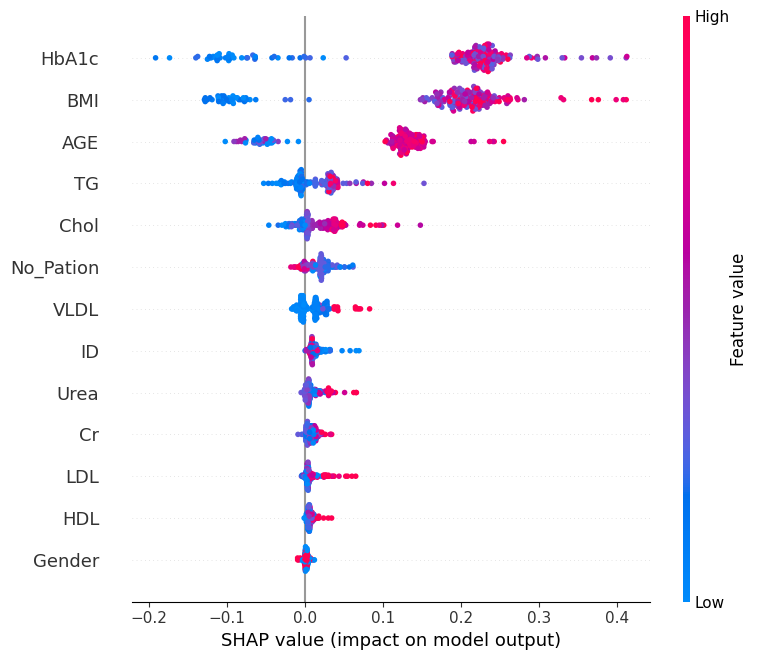

In [ ]:


import shap
import numpy as np

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# Identify class order
class_names = sorted(y.unique())
print("Class order:", class_names)

# Select class Y (Diabetic)
class_idx = class_names.index("Y")

if isinstance(shap_values, list):
    shap.summary_plot(shap_values[class_idx], X_test)
else:
    sv = np.array(shap_values)
    shap.summary_plot(sv[:, :, class_idx], X_test)

In [ ]:
## Figure 7) SHAP Local Waterfall (One patient)
This explains why the model predicted a high risk for one test case.

Number of predicted P cases: 9
Using row index: 0


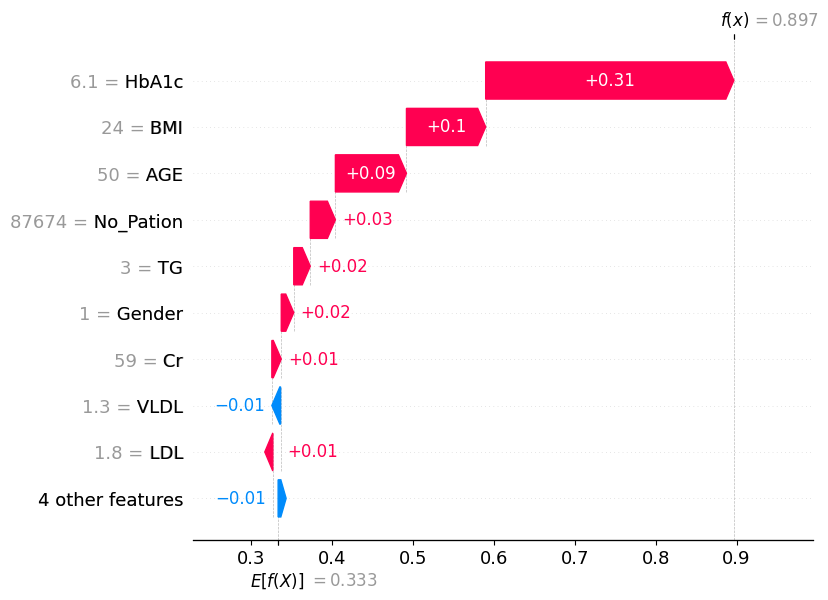

In [ ]:


import numpy as np
import shap

# Predict on test set
pred_labels = rf.predict(X_test)

# Find an index predicted as P (Prediabetic)
p_indices = np.where(pred_labels == "P")[0]
print("Number of predicted P cases:", len(p_indices))

# If none predicted as P, we'll pick one actual P instead
if len(p_indices) == 0:
    p_indices = np.where(y_test.values == "P")[0]
    print("No predicted P found, using actual P cases instead:", len(p_indices))

row_idx = int(p_indices[0])
print("Using row index:", row_idx)

class_names = sorted(y.unique())  # ['N','P','Y']
class_idx = class_names.index("P")

if isinstance(shap_values, list):
    values = shap_values[class_idx][row_idx]
    base = explainer.expected_value[class_idx]
else:
    sv = np.array(shap_values)
    values = sv[row_idx, :, class_idx]
    base = explainer.expected_value[class_idx]

exp = shap.Explanation(
    values=values,
    base_values=base,
    data=X_test.iloc[row_idx].values,
    feature_names=X_test.columns
)

shap.plots.waterfall(exp, max_display=10)

In [ ]:
# Done
All figures are generated:
- Figure 1: Class distribution
- Figure 2: TG winsorisation (histograms)
- Figure 3: 5-fold CV stability
- Figure 4: Model comparison
- Figure 5: Confusion matrix
- Figure 6: SHAP global summary
- Figure 7: SHAP local waterfall